# Solar examples

This notebook gathers the solar demos in increasing complexity.

It reproduces the physics content of:
- `solar_production_phase_space.py`
- `adiabatic_sun.py`
- `adiabatic_sun_ssm.py`
- `non_adiabatic_sun.py`
- `msw_lma_upturn.py`

The current branch does not expose the solar adiabatic helpers directly on `Oscillator`, so the notebook uses local adiabatic helper functions built from the current low-level API.

In [1]:
from pathlib import Path
import sys
import urllib.request

import numpy as np
import matplotlib.pyplot as plt

if not hasattr(np, "trapz"):
    np.trapz = np.trapezoid

repo_root = Path.cwd()
if not (repo_root / "src").exists():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root / "src"))

from nu_waves.models.mixing import Mixing
from nu_waves.models.spectrum import Spectrum
from nu_waves.matter.solar import (
    SolarProfile,
    load_bs05_agsop,
    radial_nodes_and_weights_from_pdf,
    pee_day_from_exit_fractions,
    pee_lowE_vacuum_avg,
    pee_highE_msw,
)
from nu_waves.matter.landau import landau_zener_for_pair
from nu_waves.sources.sun import SolarModel, SolarSource, R_SUN
from nu_waves.utils.units import GEV_TO_EV, VCOEFF_EV
import nu_waves.utils.style


## Shared configuration

In [2]:
angles = {(1, 2): np.deg2rad(33.4), (1, 3): np.deg2rad(8.6), (2, 3): np.deg2rad(49.0)}
phases = {(1, 3): np.deg2rad(195.0)}
dm2 = {(2, 1): 7.42e-5, (3, 2): 2.4428e-3}

mixing = Mixing(n_neutrinos=3, mixing_angles=angles, dirac_phases=phases)
spectrum = Spectrum(n_neutrinos=3, m_lightest=0.0, dm2=dm2)
U_vac = np.asarray(mixing.build_mixing_matrix())
m2 = np.asarray(spectrum.get_m2(), dtype=float)
matter_projector = np.diag([1.0, 0.0, 0.0]).astype(complex)
labels_mass = [r"$\nu_1$", r"$\nu_2$", r"$\nu_3$"]
colors_mass = ["C0", "C1", "C2"]


def ensure_bs05_table() -> Path:
    local_candidates = [
        repo_root / "notebooks" / ".cache" / "bs05_agsop.dat",
        repo_root / "examples" / "data" / "ssm" / "bs05_agsop.dat",
        repo_root / "data" / "ssm" / "bs05_agsop.dat",
    ]
    for candidate in local_candidates:
        if candidate.exists() and candidate.stat().st_size > 0:
            return candidate

    target = local_candidates[0]
    target.parent.mkdir(parents=True, exist_ok=True)
    url = "https://www.sns.ias.edu/~jnb/SNdata/Export/BS2005/bs05_agsop.dat"
    print(f"Downloading BS05 SSM table to {target} ...")
    urllib.request.urlretrieve(url, target.as_posix())
    return target


def solar_hamiltonian_flavor(E_GeV, rho_gcm3, Ye, antineutrino=False):
    E_eV = E_GeV * GEV_TO_EV
    U_eff = np.conjugate(U_vac) if antineutrino else U_vac
    H_vac = U_eff @ np.diag(m2) @ np.conjugate(U_eff.T) / (2.0 * E_eV)
    sign = -1.0 if antineutrino else 1.0
    return H_vac + sign * (VCOEFF_EV * rho_gcm3 * Ye) * matter_projector


def ordered_eigensystem_along_radius(E_GeV, profile, r_km, antineutrino=False):
    evals_all = []
    evecs_all = []
    previous = None

    for rk in np.asarray(r_km, dtype=float):
        rho = float(np.asarray(profile.rho_gcm3([rk]))[0])
        Ye = float(np.asarray(profile.Ye([rk]))[0])
        evals, evecs = np.linalg.eigh(solar_hamiltonian_flavor(E_GeV, rho, Ye, antineutrino=antineutrino))

        if previous is not None:
            overlap = np.abs(np.conjugate(previous.T) @ evecs)
            perm = []
            taken = set()
            for i in range(overlap.shape[0]):
                for j in np.argsort(overlap[i])[::-1]:
                    j = int(j)
                    if j not in taken:
                        perm.append(j)
                        taken.add(j)
                        break
            evecs = evecs[:, perm]
            evals = evals[perm]
            phases = np.angle(np.sum(np.conjugate(previous) * evecs, axis=0))
            evecs = evecs * np.exp(-1j * phases)[None, :]

        previous = evecs
        evals_all.append(evals)
        evecs_all.append(evecs)

    return np.asarray(evals_all), np.asarray(evecs_all)


def adiabatic_mass_fractions_from_emission(E_GeV, profile, r_emit_km, s_km, alpha=0, antineutrino=False):
    r_path = r_emit_km + np.asarray(s_km, dtype=float)
    evals, U_matter = ordered_eigensystem_along_radius(E_GeV, profile, r_path, antineutrino=antineutrino)
    w_matter_emit = np.abs(U_matter[0, alpha, :]) ** 2
    overlaps = np.einsum("ai,raj->rij", np.conjugate(U_vac), U_matter)
    probs_vacuum_basis = np.abs(overlaps) ** 2
    fractions = np.einsum("j,rij->ri", w_matter_emit, probs_vacuum_basis)
    return fractions, evals, U_matter


def initial_mass_compositions(E_GeV, profile, r_emit_km, alpha=0, antineutrino=False):
    F0_vacuum = np.abs(U_vac[alpha, :]) ** 2
    _, _, U_matter = adiabatic_mass_fractions_from_emission(
        E_GeV=E_GeV,
        profile=profile,
        r_emit_km=r_emit_km,
        s_km=np.array([0.0]),
        alpha=alpha,
        antineutrino=antineutrino,
    )
    F0_matter = np.abs(U_matter[0, alpha, :]) ** 2
    overlaps = np.conjugate(U_vac).T @ U_matter[0]
    F0_vacuum_from_matter = np.abs(overlaps) ** 2 @ F0_matter
    return F0_vacuum, F0_matter, F0_vacuum_from_matter


def exit_mass_fractions_single(E_GeV, profile, r_emit_km, n_steps=160, alpha=0, antineutrino=False):
    s_end = max(R_SUN - r_emit_km, 0.0)
    s_km = np.linspace(0.0, s_end, int(n_steps))
    fractions, _, _ = adiabatic_mass_fractions_from_emission(
        E_GeV=E_GeV,
        profile=profile,
        r_emit_km=r_emit_km,
        s_km=s_km,
        alpha=alpha,
        antineutrino=antineutrino,
    )
    return fractions[-1]


def exit_mass_fractions_averaged_over_radius(E_GeV_grid, profile, r_nodes_km, w_nodes, n_steps_per_ray=120):
    out = np.zeros((len(E_GeV_grid), 3), dtype=float)
    for ie, E in enumerate(E_GeV_grid):
        acc = np.zeros(3, dtype=float)
        for r_emit_km, weight in zip(r_nodes_km, w_nodes):
            acc += weight * exit_mass_fractions_single(
                E_GeV=E,
                profile=profile,
                r_emit_km=float(r_emit_km),
                n_steps=n_steps_per_ray,
            )
        out[ie] = acc
    return out


## 1. Solar production phase space

Reproduction of `solar_production_phase_space.py`.

B8: peak at r/Rsun = 0.050, 90% within r/Rsun = 0.147
Be7: peak at r/Rsun = 0.080, 90% within r/Rsun = 0.232
pp: peak at r/Rsun = 0.200, 90% within r/Rsun = 0.443


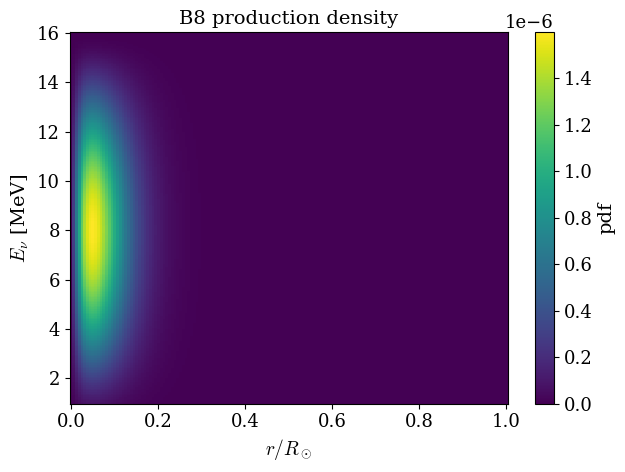

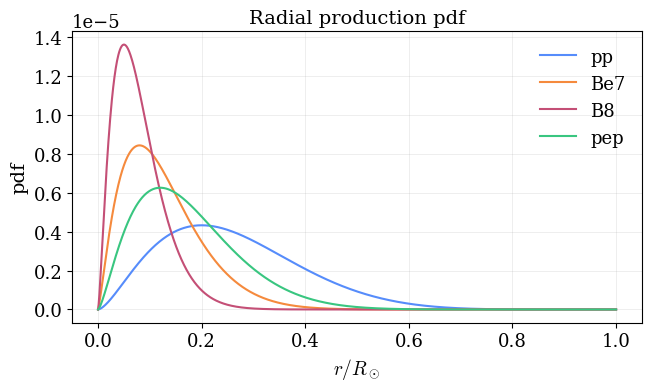

In [3]:
solar_model = SolarModel.standard_model()

for source in [SolarSource.B8, SolarSource.BE7, SolarSource.PP]:
    r = np.linspace(0.0, R_SUN, 2000)
    fr = solar_model.radial_pdf(source, r)
    fr = fr / np.trapezoid(fr, r)
    peak_r = r[np.argmax(fr)] / R_SUN
    cdf = np.concatenate([[0.0], np.cumsum(0.5 * (fr[1:] + fr[:-1]) * np.diff(r))])
    cdf = cdf / cdf[-1]
    r90 = r[np.searchsorted(cdf, 0.9)] / R_SUN
    print(f"{source.value}: peak at r/Rsun = {peak_r:.3f}, 90% within r/Rsun = {r90:.3f}")

R_grid, E_grid, f_grid = solar_model.grid(SolarSource.B8, nr=160, nE=220)

plt.figure(figsize=(6.6, 5.0))
mesh = plt.pcolormesh(R_grid / R_SUN, E_grid, f_grid, shading="auto")
plt.xlabel(r"$r/R_\odot$")
plt.ylabel(r"$E_\nu$ [MeV]")
plt.title("B8 production density")
cbar = plt.colorbar(mesh)
cbar.set_label("pdf")
plt.tight_layout()
plt.show()

r = np.linspace(0.0, R_SUN, 1200)
plt.figure(figsize=(6.8, 4.2))
for source in [SolarSource.PP, SolarSource.BE7, SolarSource.B8, SolarSource.PEP]:
    fr = solar_model.radial_pdf(source, r)
    fr = fr / np.trapezoid(fr, r)
    plt.plot(r / R_SUN, fr, label=source.value)
plt.xlabel(r"$r/R_\odot$")
plt.ylabel("pdf")
plt.title("Radial production pdf")
plt.grid(True, alpha=0.3)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


## 2. Adiabatic evolution with the analytic solar profile

Reproduction of `adiabatic_sun.py`.

Initial vacuum-basis fractions: [0.681386 0.296253 0.022361]
Initial matter-basis fractions: [0.135074 0.840646 0.02428 ]
Initial vacuum-from-matter fractions: [0.364383 0.611308 0.024309]


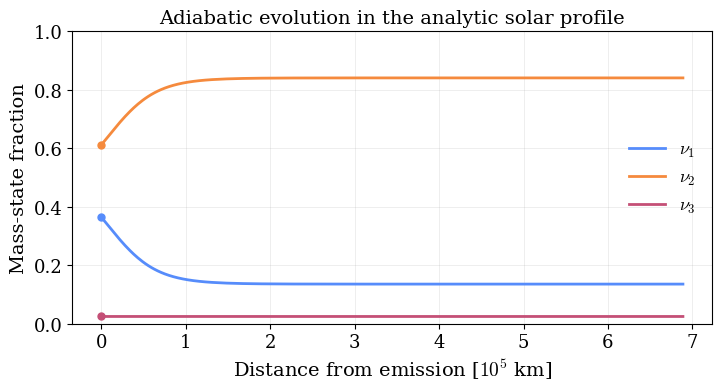

In [4]:
profile_simple = SolarProfile()
E_GeV = 0.010
r_emit = 0.01 * profile_simple.R_sun_km
s_km = np.concatenate(([0.0], np.geomspace(1.0, profile_simple.R_sun_km - r_emit, 220)))

F_simple, _, _ = adiabatic_mass_fractions_from_emission(
    E_GeV=E_GeV,
    profile=profile_simple,
    r_emit_km=r_emit,
    s_km=s_km,
    alpha=0,
)
F0_vac, F0_matter, F0_vac_from_matter = initial_mass_compositions(E_GeV, profile_simple, r_emit, alpha=0)
print("Initial vacuum-basis fractions:", np.round(F0_vac, 6))
print("Initial matter-basis fractions:", np.round(F0_matter, 6))
print("Initial vacuum-from-matter fractions:", np.round(F0_vac_from_matter, 6))

x = s_km / 1e5
plt.figure(figsize=(7.5, 4.2))
for i, (label, color) in enumerate(zip(labels_mass, colors_mass)):
    plt.plot(x, F_simple[:, i], lw=2, color=color, label=label)
    plt.scatter([x[0]], [F0_vac_from_matter[i]], s=25, color=color, zorder=5)
plt.xlabel(r"Distance from emission [$10^5$ km]")
plt.ylabel("Mass-state fraction")
plt.ylim(0.0, 1.0)
plt.title("Adiabatic evolution in the analytic solar profile")
plt.grid(True, which="both", alpha=0.3)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


## 3. Adiabatic evolution with the BS05 SSM profile

Reproduction of `adiabatic_sun_ssm.py`.

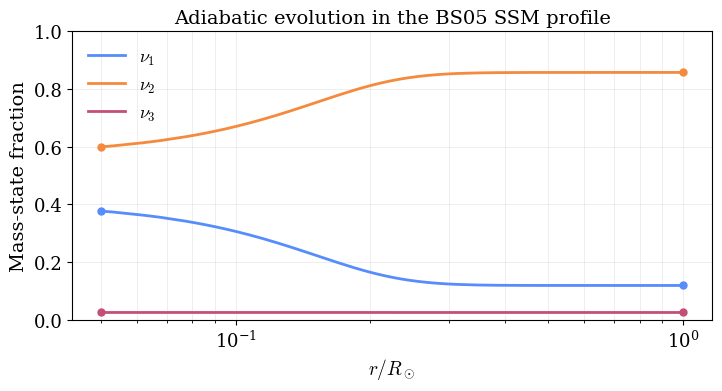

In [5]:
bs05_path = ensure_bs05_table()
profile_ssm = load_bs05_agsop(bs05_path.as_posix())

E_GeV_ssm = 0.008
r_emit_ssm = 0.05 * profile_ssm.R_sun_km
s_km_ssm = np.concatenate(([0.0], np.geomspace(1.0, profile_ssm.R_sun_km - r_emit_ssm, 220)))

F_ssm, _, _ = adiabatic_mass_fractions_from_emission(
    E_GeV=E_GeV_ssm,
    profile=profile_ssm,
    r_emit_km=r_emit_ssm,
    s_km=s_km_ssm,
    alpha=0,
)

x_ssm = (r_emit_ssm + s_km_ssm) / profile_ssm.R_sun_km
plt.figure(figsize=(7.5, 4.2))
for i, (label, color) in enumerate(zip(labels_mass, colors_mass)):
    plt.plot(x_ssm, F_ssm[:, i], lw=2, color=color, label=label)
    plt.scatter([x_ssm[0], x_ssm[-1]], [F_ssm[0, i], F_ssm[-1, i]], s=25, color=color, zorder=5)
plt.xscale("log")
plt.xlabel(r"$r/R_\odot$")
plt.ylabel("Mass-state fraction")
plt.ylim(0.0, 1.0)
plt.title("Adiabatic evolution in the BS05 SSM profile")
plt.grid(True, which="both", alpha=0.3)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


## 4. Landau-Zener non-adiabatic diagnostic

Reproduction of `non_adiabatic_sun.py`.

{'has_cross': True, 'idx_star': 205, 'r_star': 73745.04929921676, 'gap': 1.1366619877709624e-11, 'slope': 1e-12, 'Pc': 0.999999999797053}


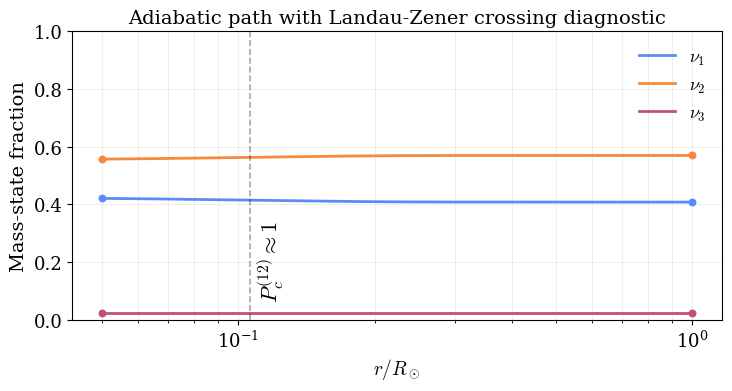

In [6]:
E_GeV_na = 0.003
r_emit_na = 0.05 * profile_ssm.R_sun_km
s_km_na = np.concatenate(([0.0], np.geomspace(1.0, profile_ssm.R_sun_km - r_emit_na, 260)))
r_path_na = r_emit_na + s_km_na

F_na, evals_na, _ = adiabatic_mass_fractions_from_emission(
    E_GeV=E_GeV_na,
    profile=profile_ssm,
    r_emit_km=r_emit_na,
    s_km=s_km_na,
    alpha=0,
)
lz_12 = landau_zener_for_pair(r_path_na, evals_na, i=0, j=1)
print(lz_12)

x_na = r_path_na / profile_ssm.R_sun_km
plt.figure(figsize=(7.6, 4.2))
for i, (label, color) in enumerate(zip(labels_mass, colors_mass)):
    plt.plot(x_na, F_na[:, i], lw=2, color=color, label=label)
    plt.scatter([x_na[0], x_na[-1]], [F_na[0, i], F_na[-1, i]], s=22, color=color, zorder=5)
if lz_12["has_cross"]:
    x_star = lz_12["r_star"] / profile_ssm.R_sun_km
    plt.axvline(x_star, ls="--", lw=1.2, color="k", alpha=0.35)
    plt.text(x_star * 1.03, 0.06, rf"$P_c^{{(12)}} \approx {lz_12['Pc']:.2g}$", rotation=90, va="bottom", ha="left")
plt.xscale("log")
plt.xlabel(r"$r/R_\odot$")
plt.ylabel("Mass-state fraction")
plt.ylim(0.0, 1.0)
plt.title("Adiabatic path with Landau-Zener crossing diagnostic")
plt.grid(True, which="both", alpha=0.3)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


## 5. Solar LMA-MSW upturn

Reproduction of `msw_lma_upturn.py`.

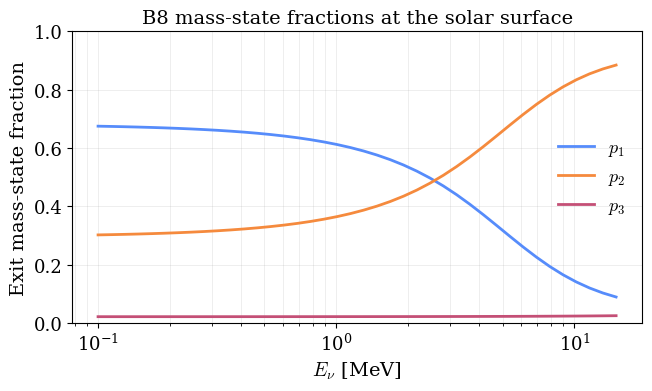

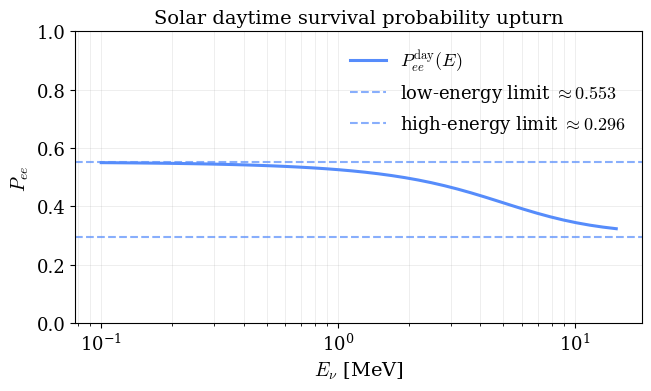

Low-energy limit  : 0.5526
High-energy limit : 0.2963
Pee(0.2 MeV)      : 0.5476
Pee(10 MeV)       : 0.3456


In [7]:
SOURCE = SolarSource.B8
N_R_NODES = 16
N_STEPS_PER_RAY = 90
E_MeV = np.logspace(np.log10(0.1), np.log10(15.0), 40)
E_GeV = 1e-3 * E_MeV

r_nodes, w_nodes = radial_nodes_and_weights_from_pdf(solar_model, SOURCE, n_nodes=N_R_NODES)
p_mass = exit_mass_fractions_averaged_over_radius(
    E_GeV_grid=E_GeV,
    profile=profile_ssm,
    r_nodes_km=r_nodes,
    w_nodes=w_nodes,
    n_steps_per_ray=N_STEPS_PER_RAY,
)

plt.figure(figsize=(6.8, 4.2))
for i in range(3):
    plt.plot(E_MeV, p_mass[:, i], lw=2, label=rf"$p_{i+1}$")
plt.xscale("log")
plt.ylim(0.0, 1.0)
plt.xlabel(r"$E_\nu$ [MeV]")
plt.ylabel("Exit mass-state fraction")
plt.title("B8 mass-state fractions at the solar surface")
plt.grid(True, which="both", alpha=0.3)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

pee_day = pee_day_from_exit_fractions(p_mass, U_vac)
pee_low = pee_lowE_vacuum_avg(U_vac)
pee_high = pee_highE_msw(U_vac, mass_index=1)

plt.figure(figsize=(6.8, 4.2))
plt.plot(E_MeV, pee_day, lw=2.2, label=r"$P_{ee}^{\rm day}(E)$")
plt.axhline(pee_low, ls="--", alpha=0.7, label=rf"low-energy limit $\approx {pee_low:.3f}$")
plt.axhline(pee_high, ls="--", alpha=0.7, label=rf"high-energy limit $\approx {pee_high:.3f}$")
plt.xscale("log")
plt.ylim(0.0, 1.0)
plt.xlabel(r"$E_\nu$ [MeV]")
plt.ylabel(r"$P_{ee}$")
plt.title("Solar daytime survival probability upturn")
plt.grid(True, which="both", alpha=0.3)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

print(f"Low-energy limit  : {pee_low:.4f}")
print(f"High-energy limit : {pee_high:.4f}")
print(f"Pee(0.2 MeV)      : {np.interp(0.2, E_MeV, pee_day):.4f}")
print(f"Pee(10 MeV)       : {np.interp(10.0, E_MeV, pee_day):.4f}")
